In [1]:
from utils.paths import DESCRIPTORS_DIR,DATABASE_DIR,RAW_DIR
from plots.PP_Processor import DataCollector
from plots.PP_Plots import Plotter
from features.SignalNoise_Process import SignalProcessor
from models_scripts.TTM_lifetime import LifetimeFitter

from data.data_loading import load_table
from data.processing import merge_data, filter_by_wavelength, predict_composition_space

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ternary

import math
import re

In [2]:
dc = DataCollector()
pl = Plotter()
sp = SignalProcessor()

In [3]:
df_compo = pd.read_excel(RAW_DIR/'1_Ternary_exp.xlsx',sheet_name='composition')
com_Cu = df_compo.sort_values("Cu",ascending=False)['Cu'].to_numpy()
com_Ni = df_compo.sort_values("Ni",ascending=False)['Ni'].to_numpy()
com_Al = df_compo.sort_values("Al",ascending=False)['Al'].to_numpy()

In [4]:
df_compo = df_compo.copy()
df_compo = df_compo.dropna()

df_compo['Cu'] = (df_compo["Cu"] * 100).round(2)
df_compo['Ni'] = (df_compo["Ni"] * 100).round(2)
df_compo['Al'] = (df_compo["Al"] * 100).round(2)

df_compo["symbol"] = (
    "Cu" + df_compo["Cu"].astype(str) +
    " Ni" + df_compo["Ni"].astype(str) +
    " Al" + df_compo["Al"].astype(str)
)

SiO2 Measurement

In [5]:
FOLDER = RAW_DIR/"_1st_bad_data_no_removed"
files_index_1, selected_1 = dc.extract_file_names(FOLDER, pattern= re.compile(
    r"""
    sample(?P<sample>\d+)          # sample1 -> 1
    .*?                            # anything in between
    pump_(?P<power>\d+)p0mW        # pump_2p0mW -> 2
    """,
    
    re.VERBOSE
),select_power='max')

In [6]:
master_wvl_1 = dc.build_master(selected_1, smooth="wvl", method="savgol", savgol_window=51, savgol_poly=3)
master_time_1 = dc.build_master(selected_1, smooth="time", method="gaussian", gaussian_sigma=3)

Transmission Measuremente

In [7]:
FOLDER = RAW_DIR/"_1st_transmission"
files_index, selected = dc.extract_file_names(FOLDER, pattern= re.compile(
    r"""
    Sample(?P<sample>\d+)        # Sample8 → 8
    .*?                          # anything in between
    (?P<power>\d+)p0mW           # 4p0mW → 4
    .*?                          # anything
    pump_                        # pump_
    """,
    
    re.VERBOSE
),select_power='max')

In [8]:
master_wvl = dc.build_master(selected, smooth="wvl", method="savgol", savgol_window=51, savgol_poly=3)
master_time = dc.build_master(selected, smooth="time", method="gaussian", gaussian_sigma=3)

In [9]:
master_time = dc.build_master(selected, smooth="time", method="savgol", savgol_window=51, savgol_poly=3)

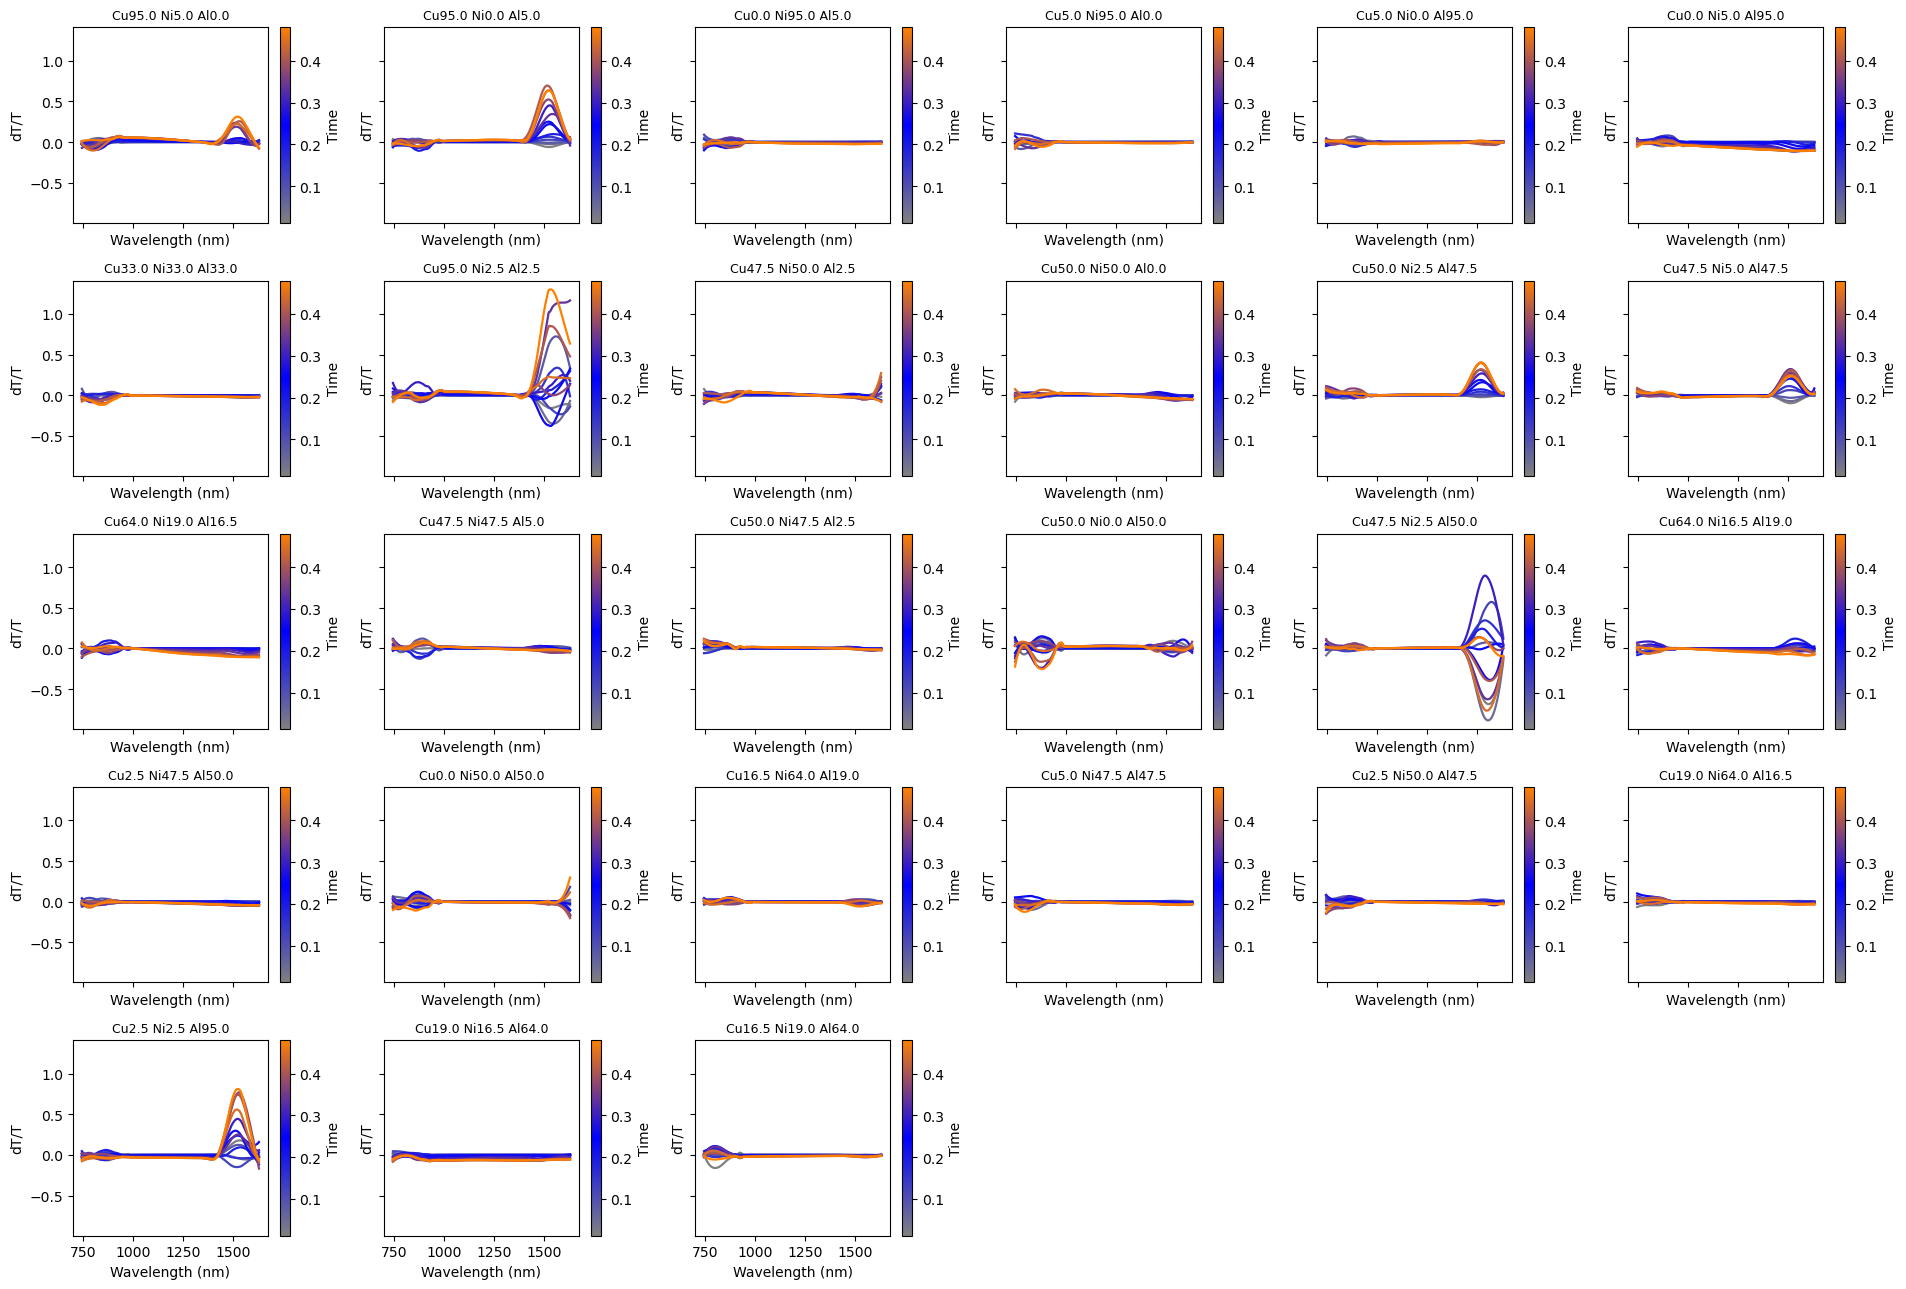

In [10]:
fig, axes = Plotter.plot_spectra_panel(
    master_wvl=master_wvl,
    df_compo=df_compo,
    ncols=6,
    time_range=(0, 0.5),
    step=3,
    legend=False,
    add_colorbar=True
)

plt.show()

Kinetic Plot

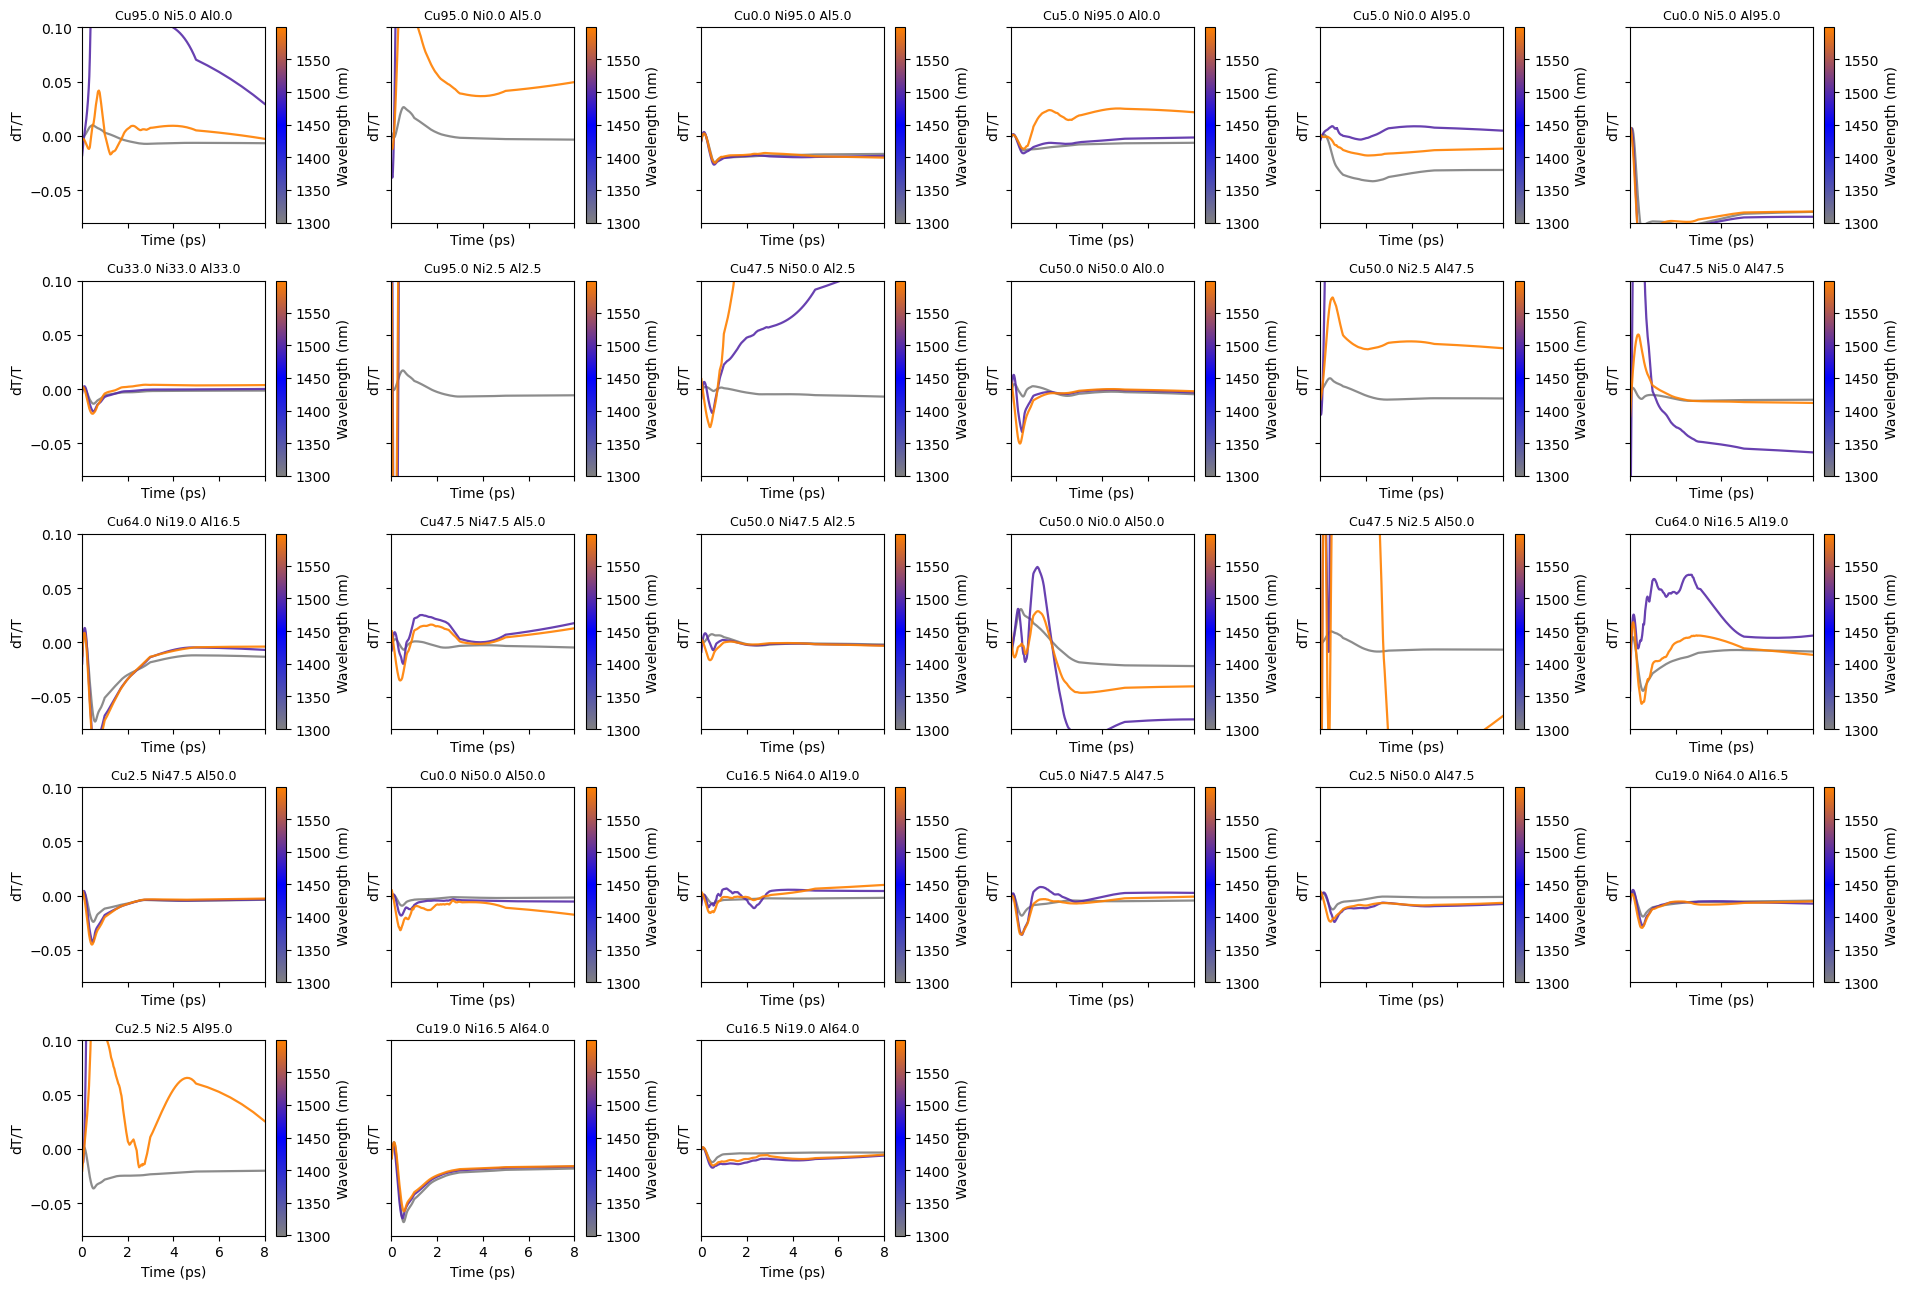

In [11]:
fig, axes = Plotter.plot_kinetics_panel(
    master_time=master_time,
    df_compo=df_compo,
    wavelengths=[1300, 1500, 1600],
    ncols=6,
    xlim=(0, 8),
    ylim=(-0.08, 0.1),
    legend=False,
    add_colorbar=True
)

plt.show()

Lifetime calculation

In [12]:
lt = LifetimeFitter()

In [13]:
results, df_lifetime = lt.fit_master_at_wavelength(
    master_time=master_time,
    wvl=1300,
    extract_params=["tau_p","r2"]
)

In [14]:
df_lifetime.head(5)
df = df_lifetime.reset_index()

In [15]:
import sqlite3
import pandas as pd


conn = sqlite3.connect(DATABASE_DIR / "Ternary_round1.db")

df.to_sql("lifetime", conn, if_exists="replace", index=False)

conn.close()

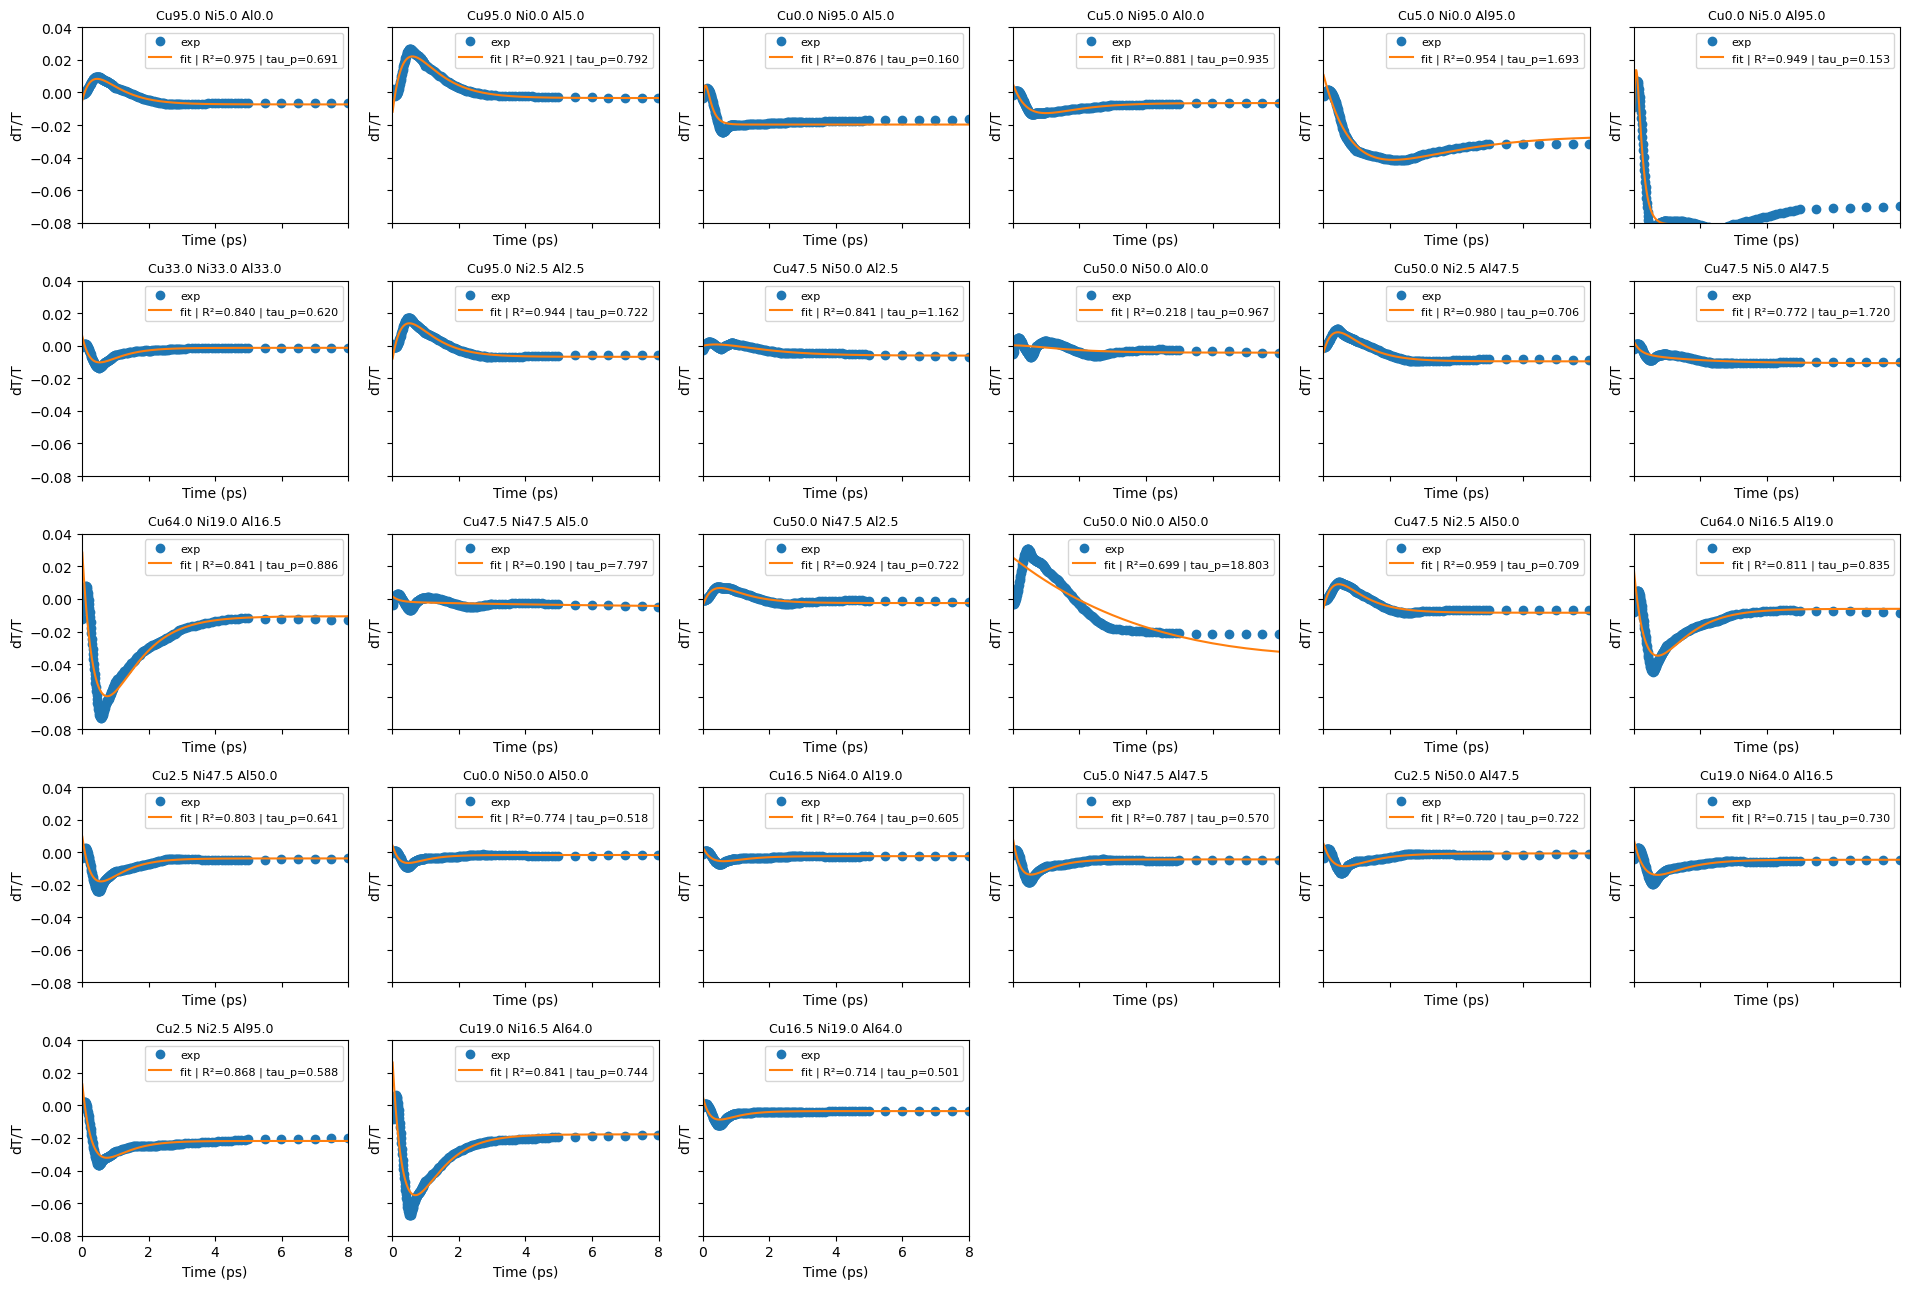

In [16]:
fig, axes = Plotter.plot_lifetime_fit_panel(
    master_time=master_time,
    lifetime_results=results,
    df_compo=df_compo,
    wvl=1300,
    ncols=6,
    time_range=(0, 8),
    ylim=(-0.08, 0.04),
    show_r2=True,
    param_name="tau_p",
    legend=True
)

plt.show()

In [17]:
keys = [3,4,5,6,7,9,12,13,18,19,20,21,22,23,24,25,26,27]
master_time_decay = {k: master_time[k] for k in keys if k in master_time}

results_decay, df_lifetime_decay = lt.fit_master_at_wavelength(
    master_time=master_time_decay,
    wvl=1300,
    extract_params=["tau_p","r2"]
)

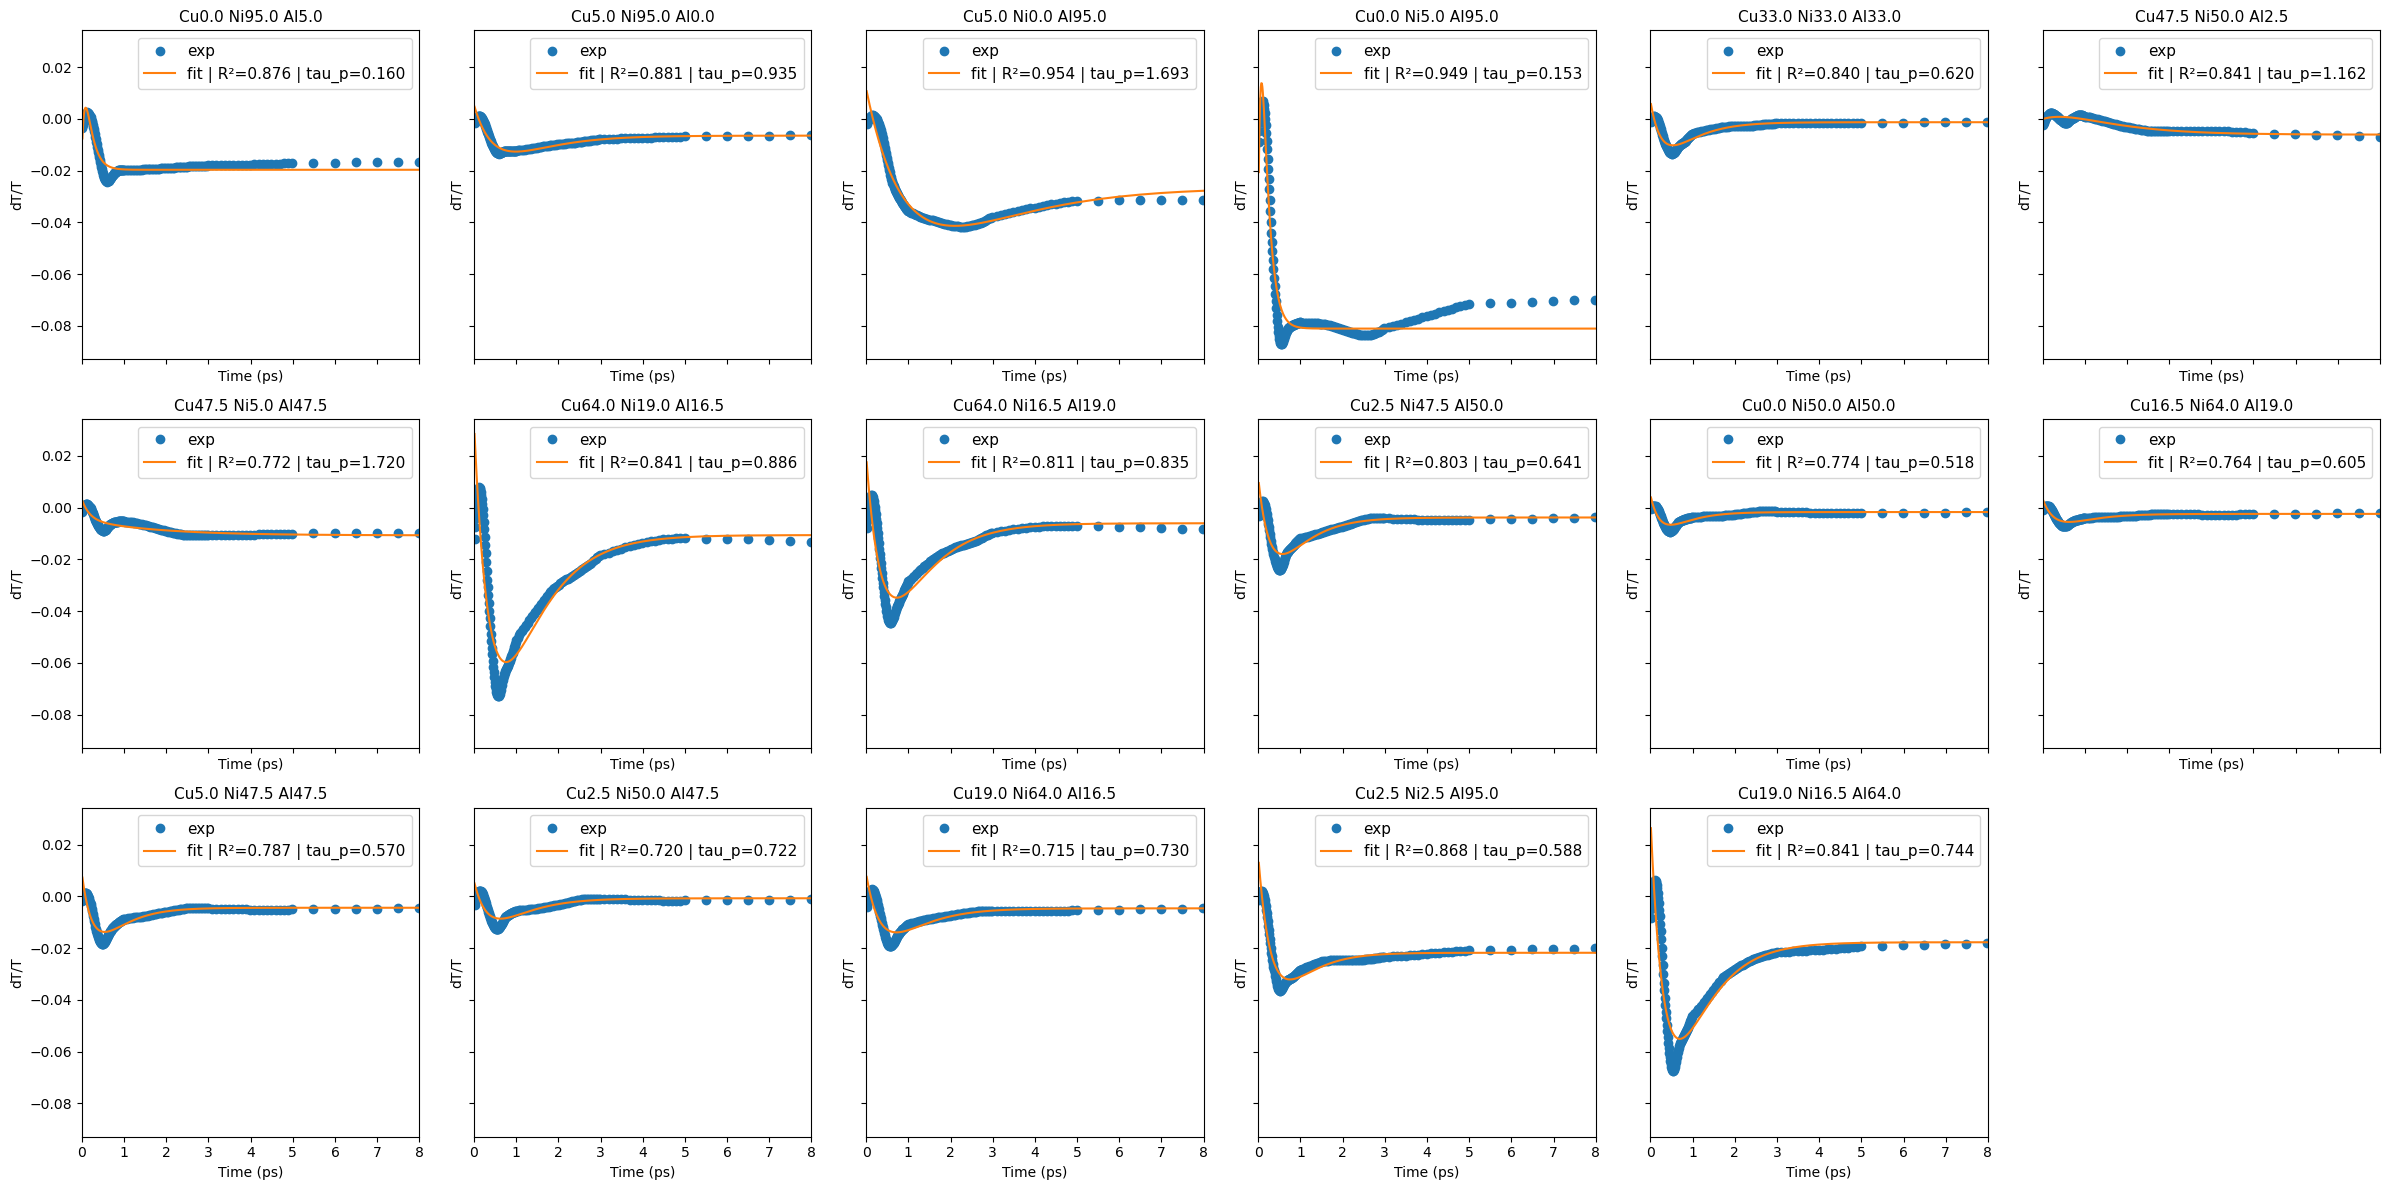

In [29]:
fig, axes = Plotter.plot_lifetime_fit_panel(
    master_time=master_time_decay,
    lifetime_results=results,
    df_compo=df_compo,
    figsize_scale = (4,4),
    wvl=1300,
    ncols=6,
    time_range=(0, 8),
    show_r2=True,
    param_name="tau_p",
    legend=True,
    legend_fontsize=11,
    title_fontsize=11
    
)

plt.show()

Lifetime equation fitting
1. Functions of the equation and the objective function
2. Find initial guesses
3. Gradient-based search to find the minimum

In [19]:
PATH_TEST = RAW_DIR / 'TTM_Test_Data.xlsx'
df_test = pd.read_excel(PATH_TEST,sheet_name='Au50Pd50')

df_test.head(5)
y_exp = df_test['dT/T exp'].to_numpy()
time_sara = df_test['time (ps)'].to_numpy()
y_fit_sara = df_test['dT/T Fit'].to_numpy()

In [20]:
lifetim_sara = lt.fit(time=time_sara, y_exp=y_exp)
residuals = lifetim_sara['residual']
y_fit_model = lifetim_sara['y_fit']

p0_sara = [-1.08e-2,0.139898,0.74371,-6.28e-2,0.017520945]

In [21]:
residual_s = (y_fit_sara - y_exp)**2
mse_s = np.mean(residual_s)
print('MSE:',mse_s)

MSE: 1.2135957117079583e-06


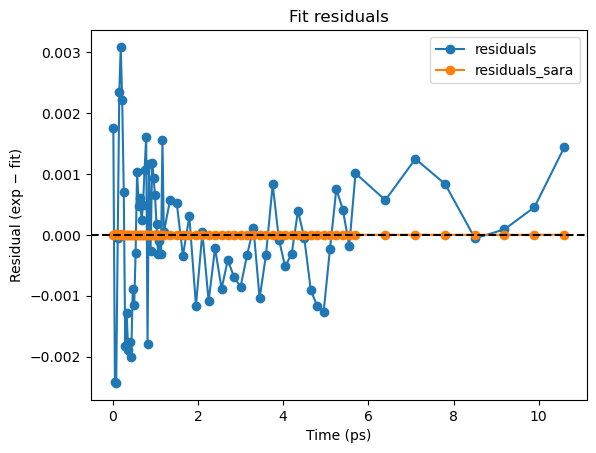

In [22]:
plt.plot(time_sara, residuals, marker='o', label='residuals')
plt.plot(time_sara, residual_s, marker='o', label='residuals_sara')

plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Time (ps)")
plt.ylabel("Residual (exp − fit)")
plt.title("Fit residuals")
plt.legend()
plt.show()

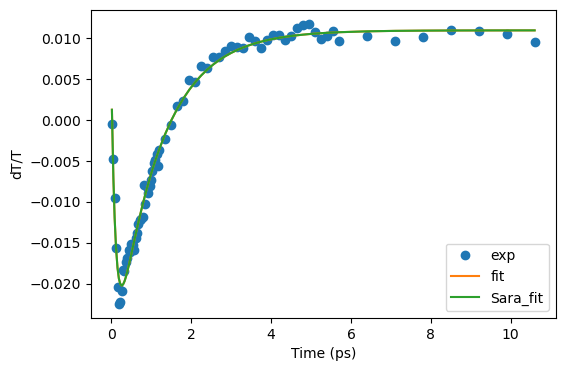

In [23]:
plt.figure(figsize=(6,4))
plt.plot(time_sara, y_exp, 'o', label="exp")
plt.plot(time_sara, y_fit_model, '-', label="fit")
plt.plot(time_sara, y_fit_sara, '-', label="Sara_fit")
plt.xlabel("Time (ps)")
plt.ylabel("dT/T")
plt.legend()
plt.show()